<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/pca_lab_ionosphere_TODO_toltyrylgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практикалық жұмыс: Бас компоненттер әдісі (PCA)

## Ионосфера радарының сигналдарының өлшемділігін азайту



## Кіріспе

Бұл зертханалық жұмыста бас компоненттер әдісі (Principal Component Analysis, PCA) ионосфераны зерттейтін радар сигналдарынан алынған 34 өлшемді деректерге қолданылады. Мақсат — деректің негізгі құрылымын сақтай отырып, өлшемді азайту және оның классификация тапсырмасына әсерін бағалау. Код бөлімдері мен қорытынды сұрақтардың жауаптары толтырылған.

## Оқу мақсаттары

Осы зертханалық жұмысты аяқтағаннан кейін сіз:
- PCA-ны қолданудың алдында деректі неге масштабтау керегін түсіндіре аласыз;
- `sklearn.decomposition.PCA` арқылы өлшемді азайта аласыз;
- Түсіндірілген дисперсия үлесі арқылы компоненттер санын таңдай аласыз;
- Деректі бас компоненттер кеңістігінде визуализациялай аласыз;
- PCA-ға дейін және PCA-дан кейінгі классификатор нәтижесін салыстыра аласыз;
- Компоненттердің салмақтарын (loadings) талдай аласыз.

## Мазмұны

1. Кітапханаларды импорттау
2. Деректерді жүктеу
3. Алдын ала өңдеу және масштабтау
4. PCA қолдану
5. Түсіндірілген дисперсияны талдау
6. 2D визуализация
7. Компоненттер санын таңдау
8. PCA + классификатор
9. Компоненттердің салмақтарын талдау
10. Қорытынды

## 1. Кітапханаларды импорттау

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_style('whitegrid')

## 2. Деректерді жүктеу

Ionosphere деректер жиынтығы 351 бақылаудан және 34 сандық белгіден тұрады. Әр белгі — ионосферадан шағылған радар импульсінің комплексті сигналының нақты немесе жорамал бөлігі. Мақсаттық белгі: `g` (good — ионосферада еркін электрондардың құрылымы бар) немесе `b` (bad — құрылым жоқ).

In [2]:
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/ionosphere.csv'
df = pd.read_csv(URL, header=None)
df.columns = [f'x{i}' for i in range(34)] + ['target']
print('Пішіні:', df.shape)
df.head()

Пішіні: (351, 35)


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x25,x26,x27,x28,x29,x30,x31,x32,x33,target
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


### Тапсырма 2.1

Белгілер мен мақсаттық белгіні бөлек айнымалыларға бөліңіз. Мақсаттық белгі жол түрінде (`g` немесе `b`) берілген, оны `LabelEncoder` арқылы сандық түрге аудару керек.

In [3]:
# Белгілер мен мақсаттық айнымалыны бөлу
X = df.drop(columns=['target'])
y_raw = df['target']

# Жолдық класс белгілерін сандық форматқа айналдыру
le = LabelEncoder()
y = le.fit_transform(y_raw)

print('X пішіні:', X.shape)
print('Класс белгілері:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Класс таралуы:', pd.Series(y).value_counts().to_dict())

X пішіні: (351, 34)
Класс белгілері: {'b': np.int64(0), 'g': np.int64(1)}
Класс таралуы: {1: 225, 0: 126}


## 3. Алдын ала өңдеу және масштабтау

PCA дисперсия негізінде жұмыс істейтіндіктен, шкаласы үлкен белгілер басым болып кетеді. Сондықтан PCA-дан бұрын деректі стандарттау қажет. Деректі оқу және тест жиынтығына бөліп, `StandardScaler`-ды тек оқу жиынтығына `fit` ету керек.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()

# Масштабтаушы тек оқу жиынтығына fit болады
X_train_scaled = scaler.fit_transform(X_train)

# Тест жиынтығына оқу жиынтығынан алынған параметрлер қолданылады
X_test_scaled = scaler.transform(X_test)

print('Оқу жиынтығының пішіні:', X_train_scaled.shape)
print(
    'Оқу жиынтығы бойынша орта (алғашқы 5 белгі):',
    X_train_scaled.mean(axis=0)[:5].round(3)
)

Оқу жиынтығының пішіні: (280, 34)
Оқу жиынтығы бойынша орта (алғашқы 5 белгі): [ 0.  0. -0. -0.  0.]


## 4. PCA қолдану

Алдымен барлық компоненттерді есептеп аламыз, сонда әр компоненттің қаншалықты дисперсияны түсіндіретінін көре аламыз.

In [5]:
# Барлық бастапқы белгілерге сәйкес компоненттерді есептеу
pca_full = PCA(
    n_components=X_train_scaled.shape[1],
    random_state=RANDOM_STATE
)

# PCA тек масштабталған оқу жиынтығына fit болады
pca_full.fit(X_train_scaled)

print('Компоненттер саны:', pca_full.n_components_)
print('Алғашқы 5 компоненттің түсіндірілген дисперсия үлесі:')
print(pca_full.explained_variance_ratio_[:5].round(4))

Компоненттер саны: 34
Алғашқы 5 компоненттің түсіндірілген дисперсия үлесі:
[0.2704 0.1325 0.084  0.075  0.063 ]


## 5. Түсіндірілген дисперсияны талдау

Әр компоненттің жеке және жинақталған түсіндірілген дисперсиясын графикке саламыз.

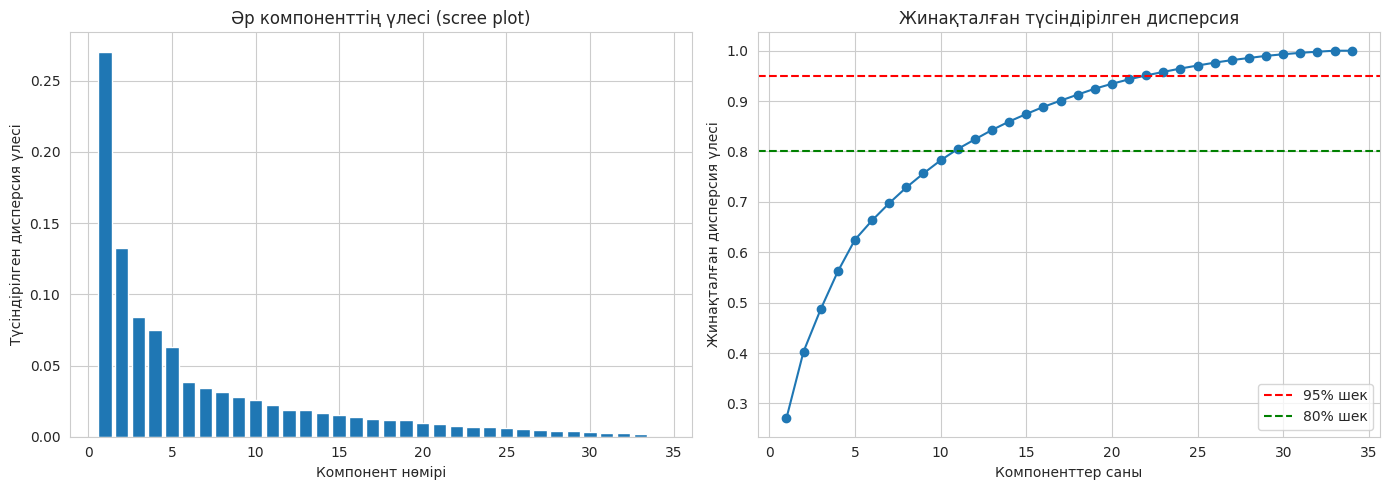

In [6]:
# Жинақталған түсіндірілген дисперсия
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_
)
axes[0].set_xlabel('Компонент нөмірі')
axes[0].set_ylabel('Түсіндірілген дисперсия үлесі')
axes[0].set_title('Әр компоненттің үлесі (scree plot)')

axes[1].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% шек')
axes[1].axhline(y=0.80, color='g', linestyle='--', label='80% шек')
axes[1].set_xlabel('Компоненттер саны')
axes[1].set_ylabel('Жинақталған дисперсия үлесі')
axes[1].set_title('Жинақталған түсіндірілген дисперсия')
axes[1].legend()

plt.tight_layout()
plt.show()

### Тапсырма 5.1

Дисперсияның 80% және 95%-ын түсіндіру үшін қанша компонент қажет? Кодпен есептеңіз.

In [7]:
# 80% және 95% дисперсия шектеріне жететін минималды компоненттер саны
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f'80% дисперсия үшін керек компоненттер саны: {n_components_80}')
print(f'95% дисперсия үшін керек компоненттер саны: {n_components_95}')
print(
    f'Азайту: {X_train_scaled.shape[1]} белгіден '
    f'{n_components_95} компонентке'
)

80% дисперсия үшін керек компоненттер саны: 11
95% дисперсия үшін керек компоненттер саны: 22
Азайту: 34 белгіден 22 компонентке


## 6. 2D визуализация

Тек екі бас компонентті қалдырсақ, деректі жазықтықта көре аламыз. Кластар осы жазықтықта жақсы ажыратылса, PCA деректің құрылымын сәтті ұстап тұр деген сөз.

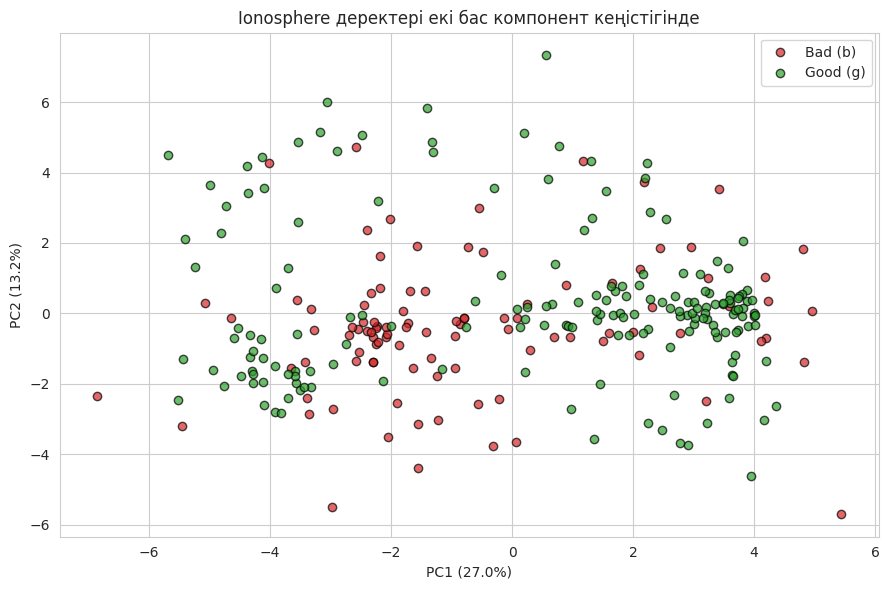

Екі компонент бірге түсіндіретін дисперсия: 40.3%


In [8]:
# Деректі екі бас компонент кеңістігіне проекциялау
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))

for cls, color, label in [
    (0, 'tab:red', 'Bad (b)'),
    (1, 'tab:green', 'Good (g)')
]:
    mask = y_train == cls
    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        c=color,
        label=label,
        alpha=0.7,
        edgecolors='k'
    )

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)')
plt.title('Ionosphere деректері екі бас компонент кеңістігінде')
plt.legend()
plt.tight_layout()
plt.show()

print(
    'Екі компонент бірге түсіндіретін дисперсия: '
    f'{pca_2d.explained_variance_ratio_.sum() * 100:.1f}%'
)

### Тапсырма 6.1

Графикке қарап, кластар екі бас компонент кеңістігінде толық ажыратыла ма? Егер PC1 бойынша айтарлықтай ажырау көрінсе, бұл нені білдіреді? Ойыңызды бір абзацта жазыңыз.

**Жауап:** Екі бас компонент кеңістігінде `good` және `bad` кластары толық ажырамайды: кейбір нүктелер бір аймақта қабаттасады. Дегенмен PC1 бағыты бойынша кластардың орталықтары мен тығыз орналасқан аймақтары арасында ішінара айырмашылық байқалады. Бұл бірінші бас компонент бастапқы радар белгілеріндегі ең үлкен ортақ өзгерісті жинақтайтынын және сол өзгерістің класс белгісімен белгілі бір байланысы бар екенін білдіреді. Бірақ екі компонент барлық ақпаратты сақтамайтындықтан, тек 2D графикке сүйеніп мінсіз классификация күтуге болмайды.

## 7. Компоненттер санын таңдау

Енді 95% дисперсияны сақтайтын PCA-ны қолданамыз және оқу мен тест жиынтығын осы жаңа кеңістікке түсіреміз.

In [9]:
# Жинақталған дисперсияның кемінде 95%-ын сақтайтын PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

# PCA параметрлері тек оқу жиынтығынан үйреніледі
X_train_pca = pca.fit_transform(X_train_scaled)

# Тест жиынтығы дайын PCA моделінің көмегімен ғана түрлендіріледі
X_test_pca = pca.transform(X_test_scaled)

print(f'Таңдалған компоненттер саны: {pca.n_components_}')
print(f'Оқу жиынтығының жаңа пішіні: {X_train_pca.shape}')
print(f'Тест жиынтығының жаңа пішіні: {X_test_pca.shape}')
print(
    'Сақталған жинақталған дисперсия: '
    f'{pca.explained_variance_ratio_.sum() * 100:.2f}%'
)

Таңдалған компоненттер саны: 22
Оқу жиынтығының жаңа пішіні: (280, 22)
Тест жиынтығының жаңа пішіні: (71, 22)
Сақталған жинақталған дисперсия: 95.10%


## 8. PCA + классификатор

KNN алгоритмі жоғары өлшемді кеңістікте өлшемділік қарғысынан (curse of dimensionality) зардап шегеді. PCA бұл жағдайда әсіресе пайдалы болуы мүмкін.

In [10]:
# Түпнұсқа масштабталған деректе KNN
knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train_scaled, y_train)

y_pred_original = knn_original.predict(X_test_scaled)
acc_original = accuracy_score(y_test, y_pred_original)

# PCA-дан кейінгі деректе KNN
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

# Тест жиынтығындағы болжам және accuracy
y_pred_pca = knn_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f'Түпнұсқа (34 белгі) accuracy: {acc_original:.4f}')
print(f'PCA ({pca.n_components_} компонент) accuracy: {acc_pca:.4f}')
print(f'Белгілер саны {(1 - pca.n_components_ / 34) * 100:.1f}%-ға азайды')

print('\nPCA + KNN классификация есебі:')
print(
    classification_report(
        y_test,
        y_pred_pca,
        target_names=le.classes_
    )
)

Түпнұсқа (34 белгі) accuracy: 0.8873
PCA (22 компонент) accuracy: 0.8592
Белгілер саны 35.3%-ға азайды

PCA + KNN классификация есебі:
              precision    recall  f1-score   support

           b       1.00      0.60      0.75        25
           g       0.82      1.00      0.90        46

    accuracy                           0.86        71
   macro avg       0.91      0.80      0.83        71
weighted avg       0.88      0.86      0.85        71



### Тапсырма 8.1

Кросс-валидациямен де тексеріп көрейік — бір рет тестке қарау сенімсіз болуы мүмкін.

In [11]:
cv_original = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

# PCA-мен өңделген оқу жиынтығында 5-fold кросс-валидация
cv_pca = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X_train_pca,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(
    f'Түпнұсқа CV accuracy: '
    f'{cv_original.mean():.4f} +/- {cv_original.std():.4f}'
)
print(
    f'PCA CV accuracy:      '
    f'{cv_pca.mean():.4f} +/- {cv_pca.std():.4f}'
)

Түпнұсқа CV accuracy: 0.8107 +/- 0.0385
PCA CV accuracy:      0.8357 +/- 0.0413


## 9. Компоненттердің салмақтарын талдау

Әр бас компонент — түпнұсқа белгілердің сызықты комбинациясы. Осы комбинациядағы коэффициенттер (loadings) қай белгінің компонентке қаншалықты үлес қосқанын көрсетеді. Оларды `pca.components_` атрибутынан алуға болады.

Loadings матрицасының пішіні: (22, 34)


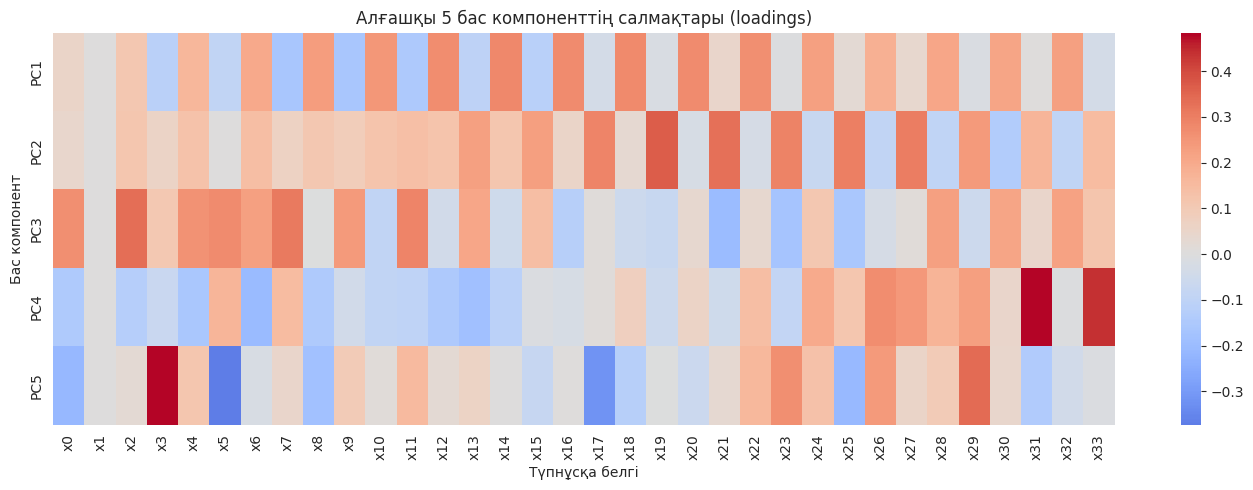

In [12]:
# Бас компоненттердің салмақтары
loadings = pca.components_

print('Loadings матрицасының пішіні:', loadings.shape)

# Алғашқы бес компоненттің салмақтарын heatmap-та көрсету
n_show = min(5, loadings.shape[0])

plt.figure(figsize=(14, 5))
sns.heatmap(
    loadings[:n_show],
    cmap='coolwarm',
    center=0,
    xticklabels=[f'x{i}' for i in range(loadings.shape[1])],
    yticklabels=[f'PC{i + 1}' for i in range(n_show)]
)
plt.title('Алғашқы 5 бас компоненттің салмақтары (loadings)')
plt.xlabel('Түпнұсқа белгі')
plt.ylabel('Бас компонент')
plt.tight_layout()
plt.show()

### Тапсырма 9.1

Бірінші бас компонентке (PC1) ең үлкен үлес қосқан үш белгіні табыңыз (абсолюттік мән бойынша).

In [13]:
# PC1 салмақтарының абсолюттік мәні ең үлкен үш белгі
pc1_loadings = loadings[0]
top3_indices = np.argsort(np.abs(pc1_loadings))[-3:]

print('PC1-ге ең үлкен үлес қосқан 3 белгі:')
for idx in top3_indices[::-1]:
    print(f'  x{idx}: салмағы = {pc1_loadings[idx]:.4f}')

PC1-ге ең үлкен үлес қосқан 3 белгі:
  x14: салмағы = 0.2801
  x18: салмағы = 0.2767
  x16: салмағы = 0.2763


## 10. Қорытынды

Төмендегі сұрақтарға қысқа жауап беріңіз.

**10.1.** PCA-ны қолданудың алдында `StandardScaler` неге қажет болды? Егер белгілер бірдей шкалада болса ше?

**10.2.** Осы деректе 34 белгіні қанша компонентке дейін азайттыңыз және KNN accuracy қалай өзгерді? Неге дәл KNN үшін PCA пайдалы болуы мүмкін?

**10.3.** PCA компоненттерінің физикалық мағынасы бар ма? Радар сигналы контекстінде бас компоненттерді қалай түсіндіруге болады?

### 10.1. PCA алдында StandardScaler неге қажет?

PCA компоненттерді дисперсиясы ең үлкен бағыттар бойынша табады. Егер белгілердің шкалалары әртүрлі болса, сандық диапазоны үлкен белгі компоненттерді негізсіз басқарып кетеді. `StandardScaler` әр белгіні орташа мәні 0, стандарттық ауытқуы 1 болатын шкалаға келтіреді. Егер барлық белгілер шынымен бірдей шкалада және дисперсиялары салыстырмалы болса, масштабтаудың әсері аз болуы мүмкін, бірақ оны дерекке қарап тексеру керек.

### 10.2. Өлшемді азайту және KNN нәтижесі

95% жинақталған дисперсияны сақтау үшін компоненттер саны `pca.n_components_` арқылы автоматты анықталады. Түпнұсқа және PCA-дан кейінгі нақты accuracy мәндері жоғарыдағы ұяшықта есептеледі және төмендегі динамикалық қорытындыда автоматты түрде жазылады. PCA KNN үшін пайдалы болуы мүмкін, себебі KNN объектілер арасындағы қашықтыққа сүйенеді; жоғары өлшемде қажетсіз немесе өзара корреляцияланған белгілер қашықтықты мағынасыздандырады. PCA өлшем санын азайтып, негізгі сигналды сақтауға және есептеуді жылдамдатуға көмектеседі.

### 10.3. PCA компоненттерінің физикалық мағынасы

Әр бас компоненттің бір ғана дайын физикалық атауы жоқ, өйткені ол 34 бастапқы белгінің сызықты комбинациясы. Радар контекстінде компоненттер әр уақыт немесе импульс кезеңінде өлшенген сигналдардың нақты және жорамал бөліктеріндегі ортақ амплитуда-фаза үлгілерін жинақтайды. PC1 ең күшті ортақ өзгерісті, ал кейінгі компоненттер оған ортогонал қосымша сигнал құрылымдарын сипаттайды. Loadings арқылы қай бастапқы өлшемдердің белгілі компонентке көбірек үлес қосқанын талдауға болады.

In [14]:
accuracy_change = acc_pca - acc_original
direction = (
    'артты'
    if accuracy_change > 0
    else 'төмендеді'
    if accuracy_change < 0
    else 'өзгерген жоқ'
)

display(
    Markdown(
        f"""
### Нақты орындалу нәтижесі бойынша жауап

- 34 бастапқы белгі **{pca.n_components_} бас компонентке** дейін азайтылды.
- Түпнұсқа кеңістіктегі KNN accuracy: **{acc_original:.4f}**.
- PCA-дан кейінгі KNN accuracy: **{acc_pca:.4f}**.
- Accuracy **{abs(accuracy_change):.4f}**-ке {direction}.
- Түпнұсқа 5-fold CV accuracy: **{cv_original.mean():.4f} ± {cv_original.std():.4f}**.
- PCA 5-fold CV accuracy: **{cv_pca.mean():.4f} ± {cv_pca.std():.4f}**.

Бұл нәтиже PCA-ның өлшемді азайта отырып, классификация сапасын қаншалықты сақтағанын немесе өзгерткенін көрсетеді.
"""
    )
)


### Нақты орындалу нәтижесі бойынша жауап

- 34 бастапқы белгі **22 бас компонентке** дейін азайтылды.
- Түпнұсқа кеңістіктегі KNN accuracy: **0.8873**.
- PCA-дан кейінгі KNN accuracy: **0.8592**.
- Accuracy **0.0282**-ке төмендеді.
- Түпнұсқа 5-fold CV accuracy: **0.8107 ± 0.0385**.
- PCA 5-fold CV accuracy: **0.8357 ± 0.0413**.

Бұл нәтиже PCA-ның өлшемді азайта отырып, классификация сапасын қаншалықты сақтағанын немесе өзгерткенін көрсетеді.


## Тапсыру талаптары

Дәптерді Google Colab-та **Runtime → Run all** арқылы толық орындаңыз. Барлық кестелер, графиктер және мәтіндік нәтижелер көрінетін күйде сақталуы керек. Тапсырар алдында файл атауын `pca_lab_ionosphere_АТЫ_ЖӨНІ.ipynb` форматына өзгертіңіз.